In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def Zero_Sum_Gauge(J,h):
	"""
	Function to apply a zero-sum gauge transformation to J and h matrices.
	"""
	if J is None:
		L,q = h.shape
		J = np.zeros((L,L,q,q))
		h_zg = np.copy(h)
		h_zg -= np.expand_dims(np.mean(h,axis = 1),axis = 1) 
		h_zg += np.sum(np.mean(J,axis=3)-np.expand_dims(np.mean(J,axis=(2,3)),axis=2),axis=1)
		return None,h_zg
	
	if h is None:
		L,q = J.shape[0],J.shape[2]
		J_zg = np.copy(J)
		J_zg -= np.expand_dims(np.mean(J,axis = 2),axis = 2) 
		J_zg -= np.expand_dims(np.mean(J,axis=3),axis =3) 
		J_zg += np.expand_dims(np.mean(J,axis=(2,3)),axis=(2,3))
		return J_zg, None

	J_zg = np.copy(J)
	h_zg = np.copy(h)

	h_zg -= np.expand_dims(np.mean(h,axis = 1),axis = 1) 
	h_zg += np.sum(np.mean(J,axis=3)-np.expand_dims(np.mean(J,axis=(2,3)),axis=2),axis=1)

	J_zg -= np.expand_dims(np.mean(J,axis = 2),axis = 2) 
	J_zg -= np.expand_dims(np.mean(J,axis=3),axis =3) 
	J_zg += np.expand_dims(np.mean(J,axis=(2,3)),axis=(2,3))

	return J_zg, h_zg

def Mutational_effect(WT_seq,h,J):
	"""
	Function to compute mutational effects based on the provided wild-type sequence, h, and J values, 
	considering the changes in energy resulting from single amino acid substitutions.
	"""
	L,q = h.shape
	Mut = np.zeros((q,L))
	for k in range(L):
		for b in range(q):
			if b != WT_seq[k]:
				Delta_E = h[k,WT_seq[k]] - h[k,b] - np.sum(J[k,np.arange(L),b,WT_seq]) + np.sum(J[k,np.arange(L),WT_seq[k],WT_seq]) 
				Mut[b,k] = Delta_E
	return Mut

def next_mutation(J, h, seq_wt, pinned_mutations):
    """
    Propose next mutation using the same logic as Propose_Mutation_DDE2,
    but only with raw array indices (no reference-position mapping).

    Parameters
    ----------
    J, h : model parameters
        Same objects used by ut.Mutational_effect.
    seq_wt : np.ndarray, shape (L,)
        WT sequence encoded as AA indices (0..q-1).
    pinned_mutations : list of (mut_aa_idx, site_idx)
        Example after D189S and Y228F (in your array indexing):
        [(16, i_D189), (5, i_Y228)]  # if S=16, F=5 in your alphabet.

    Returns
    -------
    next_mut : tuple (aa_idx, site_idx, score)
        Best next mutation (global minimum of Mut_diff after masking pinned sites).
    mut_diff : np.ndarray
        Full matrix Mut_pred(seq_cur) - Mut_pred(seq_wt), masked at pinned sites.
    seq_cur : np.ndarray
        Sequence with pinned mutations applied.
    """
    # Build current sequence with pinned mutations
    seq_cur = np.array(seq_wt, copy=True)
    for mut_aa_idx, site_idx in pinned_mutations:
        seq_cur[site_idx] = mut_aa_idx

    # Same baseline as Propose_Mutation_DDE2
    mut_pred_wt = Mutational_effect(seq_wt, h, J)
    mut_pred_cur = Mutational_effect(seq_cur, h, J)
    mut_diff = mut_pred_cur - mut_pred_wt

    # Mask already mutated sites (same behavior)
    for _, site_idx in pinned_mutations:
        mut_diff[:, site_idx] = np.nan

    # Pick global minimum
    aa_idx, site_idx = np.unravel_index(np.nanargmin(mut_diff), mut_diff.shape)
    score = float(mut_diff[aa_idx, site_idx])

    return (int(aa_idx), int(site_idx), score), mut_diff, seq_cur

In [3]:
nums = np.array(['16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '37', '37a', '37b', '37c', '37d', '37e', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '61a', '61b', '61c', '61d', '61e', '61f', '61g', '62', '63', '64', '66', '67', '68', '69', '70', '71', '72', '73', '74', '74a', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '96a', '96b', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '121a', '122', '123', '124', '125', '125a', '125b', '125c', '127', '128', '129', '130', '130a', '132', '133', '133a', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '148a', '148b', '148c', '148d', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '173a', '173b', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '184A', '185', '186', '187', '188', '188A', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '202a', '202b', '202c', '202d', '202e', '203', '204', '209', '210', '211', '212', '213', '214', '215', '216', '217', '217a', '217b', '219', '220', '221', '221A', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '245a', '245b', '245c'])

In [4]:
alphabet = "-ACDEFGHIKLMNPQRSTVWY"
AA_2_NUM = {aa: i for i, aa in enumerate(alphabet)}
try2_rat_seq = """
IVGGYTCQENSVPYQVSLNS-----GYHFCGGSLINDQWVVSAAHCYKS-------RIQV
RLGEHNIN-VLEGNEQFVNAAKIIKHPNFDR--KTLNNDIMLIKLSSPVKLNARVATV-A
LPS---SCAP-AG-TQCLISGWGNTLSSG----VNEPDLLQCLDAPLLPQADCEASYP--
GKITDNMVCVGFLEGGKDSCQGDSGGPVVCN-----GELQGIVSWGY--GCALPDNPGVY
TKVCNYVDWIQDTIAAN---
"""
try2_rat_seq = try2_rat_seq.replace("\n", "")
try2_rat_seq_int = np.array([AA_2_NUM[e] for e in try2_rat_seq])

In [16]:
np.where(nums == '221')

(array([231]),)

In [6]:
try2_rat_seq[197]

'D'

In [7]:
np.array([l for l in try2_rat_seq])[239:]

array(['Y', 'T', 'K', 'V', 'C', 'N', 'Y', 'V', 'D', 'W', 'I', 'Q', 'D',
       'T', 'I', 'A', 'A', 'N', '-', '-', '-'], dtype='<U1')

In [8]:
AA_2_NUM

{'-': 0,
 'A': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'K': 9,
 'L': 10,
 'M': 11,
 'N': 12,
 'P': 13,
 'Q': 14,
 'R': 15,
 'S': 16,
 'T': 17,
 'V': 18,
 'W': 19,
 'Y': 20}

In [9]:
def compensatory_ddes(J, i = 197, j = 237, alpha = 3, beta = 16, gamma = 6):
    # This function returns as an output the values of DeltaDeltaE of
    # residue j going from amino acid gamma to delta
    # where z = {-, A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y}
    # given that i has been mutated from amino acid alpha to beta
    
    # we should compute the DeltaDeltaE for making the D189S mutation
    # and then computing the energies of mutations for position G226.
    # since in the sector definition G226 is in index 20, and D189 is
    # in index 11, we will change these indices. remember that the
    # indexing is res number, res number, aa number, aa number.

    delta = np.arange(21)    # all amino-acid indices

    DeltaDeltaE = ( J[i, j, alpha, delta] + J[i, j, beta, gamma]
                  - J[i, j, beta, delta] - J[i, j, alpha, gamma] )
    
    return DeltaDeltaE

In [11]:
POS_ALIGN_Yip = np.array(['16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '37', '37a', '37b', '37c', '37d', '37e', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '61a', '61b', '61c', '61d', '61e', '61f', '61g', '62', '63', '64', '66', '67', '68', '69', '70', '71', '72', '73', '74', '74a', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '96a', '96b', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '121a', '122', '123', '124', '125', '125a', '125b', '125c', '127', '128', '129', '130', '130a', '132', '133', '133a', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '148a', '148b', '148c', '148d', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '173a', '173b', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '184A', '185', '186', '187', '188', '188A', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '202a', '202b', '202c', '202d', '202e', '203', '204', '209', '210', '211', '212', '213', '214', '215', '216', '217', '217a', '217b', '219', '220', '221', '221A', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '245a', '245b', '245c'])
SEQ_3TGI_YIP = 'IVGGYTCQENSVPYQVSLNS-----GYHFCGGSLINDQWVVSAAHCYKS-------RIQVRLGEHNIN-VLEGNEQFVNAAKIIKHPNFDR--KTLNNDIMLIKLSSPVKLNARVATV-ALPS---SCAP-AG-TQCLISGWGNTLSSG----VNEPDLLQCLDAPLLPQADCEASYP--GKITDNMVCVGFLEGGKDSCQGDSGGPVVCN-----GELQGIVSWGY--GCALPDNPGVYTKVCNYVDWIQDTIAAN---'
SEQ_1T8O_YIP = 'IVNGEEAVPGSWPWQVSLQDK---TGFHFCGGSLINENWVVTAAHCGVT------TSDVVVAGEFDQG-SSSEKIQKLKIAKVFKNSKYNS--LTINNDITLLKLSTAASFSQTVSAVC-LPSAS--DDFAAG-TTCVTTGWGLT-RY--TNA-NTPDRLQQASLPLLSNTNCKKYWG--TKIKDAMICAGASGV--SSCMGDSGGPLVCKKN-GAWTLVGIVSWGSS-TCSTS-TPGVYARVTALVNWVQQTLAAN---'
CODE = alphabet

def Propose_Mutation_DDE2_mod(J , h ,Nb_mut,Mutations,Np=10,POS_ALIGN = None,SEQ_REF = None):
	## slightly different version of the same function above, that is fed h and J directly instead of model path
	J,h = Zero_Sum_Gauge(J,h)

	seq_tryp = np.array([AA_2_NUM[SEQ_REF[i]] for i in range(len(SEQ_REF))])

	Ind_proposed = []
	for Mut in Mutations:
		seq_mut = np.copy(seq_tryp)
		seq_mut[np.where(POS_ALIGN==Mut[1])[0][0]] = AA_2_NUM[Mut[0]]

		Ind_proposed.append((AA_2_NUM[Mut[0]],np.where(POS_ALIGN==Mut[1])[0][0]))

	Mut_pred_WT = Mutational_effect(seq_tryp,h,J)

	seq_ref = np.copy(seq_mut)

	if Nb_mut>0:
		for mut in range(Nb_mut):

			Mut_pred = Mutational_effect(seq_ref,h,J)

			Mut_diff = Mut_pred - Mut_pred_WT

			for ind in Ind_proposed:
				Mut_diff[:,ind[1]] = np.nan

			ind_min = np.unravel_index(np.nanargmin(Mut_diff, axis=None), Mut_diff.shape)
			Ind_proposed.append(ind_min)
			sig_mut = ind_min[0]

			if mut < Np:
				print(f"Mutation {mut + 2}: {CODE[seq_ref[ind_min[1]]]}{POS_ALIGN[ind_min[1]]}{CODE[sig_mut]}   ΔΔE = {Mut_diff[ind_min]:.2f}")
			seq_ref[ind_min[1]] = sig_mut

	return Ind_proposed
    # [('S','189')]

In [42]:
J.shape, h.shape

((23, 23, 21, 21), (23, 21))

In [58]:
seq_mut = np.array([AA_2_NUM[SEQ_3TGI_YIP[i]] for i in range(len(SEQ_3TGI_YIP))])

In [61]:
Mut = ("S", "189")

In [62]:
seq = np.array([e for e in SEQ_3TGI_YIP])

In [69]:
seq

array(['I', 'V', 'G', 'G', 'Y', 'T', 'C', 'Q', 'E', 'N', 'S', 'V', 'P',
       'Y', 'Q', 'V', 'S', 'L', 'N', 'S', '-', '-', '-', '-', '-', 'G',
       'Y', 'H', 'F', 'C', 'G', 'G', 'S', 'L', 'I', 'N', 'D', 'Q', 'W',
       'V', 'V', 'S', 'A', 'A', 'H', 'C', 'Y', 'K', 'S', '-', '-', '-',
       '-', '-', '-', '-', 'R', 'I', 'Q', 'V', 'R', 'L', 'G', 'E', 'H',
       'N', 'I', 'N', '-', 'V', 'L', 'E', 'G', 'N', 'E', 'Q', 'F', 'V',
       'N', 'A', 'A', 'K', 'I', 'I', 'K', 'H', 'P', 'N', 'F', 'D', 'R',
       '-', '-', 'K', 'T', 'L', 'N', 'N', 'D', 'I', 'M', 'L', 'I', 'K',
       'L', 'S', 'S', 'P', 'V', 'K', 'L', 'N', 'A', 'R', 'V', 'A', 'T',
       'V', '-', 'A', 'L', 'P', 'S', '-', '-', '-', 'S', 'C', 'A', 'P',
       '-', 'A', 'G', '-', 'T', 'Q', 'C', 'L', 'I', 'S', 'G', 'W', 'G',
       'N', 'T', 'L', 'S', 'S', 'G', '-', '-', '-', '-', 'V', 'N', 'E',
       'P', 'D', 'L', 'L', 'Q', 'C', 'L', 'D', 'A', 'P', 'L', 'L', 'P',
       'Q', 'A', 'D', 'C', 'E', 'A', 'S', 'Y', 'P', '-', '-', 'G

In [64]:
seq_mut[np.where(POS_ALIGN_Yip==Mut[1])[0][0]] = AA_2_NUM[Mut[0]]

In [67]:
(AA_2_NUM[Mut[0]],np.where(POS_ALIGN_Yip==Mut[1])[0][0])

(16, np.int64(197))

In [68]:
Mut_pred_WT = Mutational_effect(seq_tryp,h,J)

NameError: name 'seq_tryp' is not defined

In [65]:
seq_mut

array([ 8, 18,  6,  6, 20, 17,  2, 14,  4, 12, 16, 18, 13, 20, 14, 18, 16,
       10, 12, 16,  0,  0,  0,  0,  0,  6, 20,  7,  5,  2,  6,  6, 16, 10,
        8, 12,  3, 14, 19, 18, 18, 16,  1,  1,  7,  2, 20,  9, 16,  0,  0,
        0,  0,  0,  0,  0, 15,  8, 14, 18, 15, 10,  6,  4,  7, 12,  8, 12,
        0, 18, 10,  4,  6, 12,  4, 14,  5, 18, 12,  1,  1,  9,  8,  8,  9,
        7, 13, 12,  5,  3, 15,  0,  0,  9, 17, 10, 12, 12,  3,  8, 11, 10,
        8,  9, 10, 16, 16, 13, 18,  9, 10, 12,  1, 15, 18,  1, 17, 18,  0,
        1, 10, 13, 16,  0,  0,  0, 16,  2,  1, 13,  0,  1,  6,  0, 17, 14,
        2, 10,  8, 16,  6, 19,  6, 12, 17, 10, 16, 16,  6,  0,  0,  0,  0,
       18, 12,  4, 13,  3, 10, 10, 14,  2, 10,  3,  1, 13, 10, 10, 13, 14,
        1,  3,  2,  4,  1, 16, 20, 13,  0,  0,  6,  9,  8, 17,  3, 12, 11,
       18,  2, 18,  6,  5, 10,  4,  6,  6,  9, 16, 16,  2, 14,  6,  3, 16,
        6,  6, 13, 18, 18,  2, 12,  0,  0,  0,  0,  0,  6,  4, 10, 14,  6,
        8, 18, 16, 19,  6

In [40]:
aa_to_int = np.vectorize({aa: i for i, aa in enumerate(alphabet)}.get)
aa_to_int(seq)

array([ 8, 18,  6,  6, 20, 17,  2, 14,  4, 12, 16, 18, 13, 20, 14, 18, 16,
       10, 12, 16,  0,  0,  0,  0,  0,  6, 20,  7,  5,  2,  6,  6, 16, 10,
        8, 12,  3, 14, 19, 18, 18, 16,  1,  1,  7,  2, 20,  9, 16,  0,  0,
        0,  0,  0,  0,  0, 15,  8, 14, 18, 15, 10,  6,  4,  7, 12,  8, 12,
        0, 18, 10,  4,  6, 12,  4, 14,  5, 18, 12,  1,  1,  9,  8,  8,  9,
        7, 13, 12,  5,  3, 15,  0,  0,  9, 17, 10, 12, 12,  3,  8, 11, 10,
        8,  9, 10, 16, 16, 13, 18,  9, 10, 12,  1, 15, 18,  1, 17, 18,  0,
        1, 10, 13, 16,  0,  0,  0, 16,  2,  1, 13,  0,  1,  6,  0, 17, 14,
        2, 10,  8, 16,  6, 19,  6, 12, 17, 10, 16, 16,  6,  0,  0,  0,  0,
       18, 12,  4, 13,  3, 10, 10, 14,  2, 10,  3,  1, 13, 10, 10, 13, 14,
        1,  3,  2,  4,  1, 16, 20, 13,  0,  0,  6,  9,  8, 17,  3, 12, 11,
       18,  2, 18,  6,  5, 10,  4,  6,  6,  9,  3, 16,  2, 14,  6,  3, 16,
        6,  6, 13, 18, 18,  2, 12,  0,  0,  0,  0,  0,  6,  4, 10, 14,  6,
        8, 18, 16, 19,  6

In [13]:
fullaln_models_folder = Path("../models/BootstrapModels/")
ddes_list = []
for fullaln_model in fullaln_models_folder.glob("*.npy"):
    model = np.load(fullaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    Propose_Mutation_DDE2_mod(J, h, 3, [('D','189')], POS_ALIGN=POS_ALIGN_Yip, SEQ_REF=SEQ_1T8O_YIP)
    print("\n")

Mutation 2: S217a-   ΔΔE = -0.53
Mutation 3: -223N   ΔΔE = -0.75
Mutation 4: -188G   ΔΔE = -1.10


Mutation 2: S217a-   ΔΔE = -0.48
Mutation 3: -188G   ΔΔE = -0.81
Mutation 4: -223N   ΔΔE = -1.32


Mutation 2: S217a-   ΔΔE = -0.56
Mutation 3: S221A   ΔΔE = -0.95
Mutation 4: -188G   ΔΔE = -1.11


Mutation 2: S221A   ΔΔE = -0.50
Mutation 3: -223G   ΔΔE = -0.83
Mutation 4: -188G   ΔΔE = -1.20


Mutation 2: -223G   ΔΔE = -0.31
Mutation 3: -188G   ΔΔE = -0.51
Mutation 4: -188AK   ΔΔE = -0.68


Mutation 2: S217a-   ΔΔE = -0.66
Mutation 3: S221A   ΔΔE = -1.06
Mutation 4: -223N   ΔΔE = -1.27


Mutation 2: -223G   ΔΔE = -0.33
Mutation 3: -188G   ΔΔE = -0.63
Mutation 4: -188AK   ΔΔE = -0.90


Mutation 2: -223G   ΔΔE = -0.62
Mutation 3: S217a-   ΔΔE = -0.81
Mutation 4: -188G   ΔΔE = -1.29


Mutation 2: -223G   ΔΔE = -0.41
Mutation 3: -188G   ΔΔE = -0.68
Mutation 4: -188AK   ΔΔE = -0.96


Mutation 2: S217a-   ΔΔE = -0.52
Mutation 3: -188G   ΔΔE = -0.84
Mutation 4: -188AK   ΔΔE = -1.54




In [43]:
fullaln_models_folder = Path("../models/BootstrapModels/")
ddes_list = []
for fullaln_model in fullaln_models_folder.glob("*.npy"):
    model = np.load(fullaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    ddes_list.append(compensatory_ddes(J, i = 197, j = 231, alpha = 16, beta = 3, gamma = 16))

IndexError: index 197 is out of bounds for axis 0 with size 23

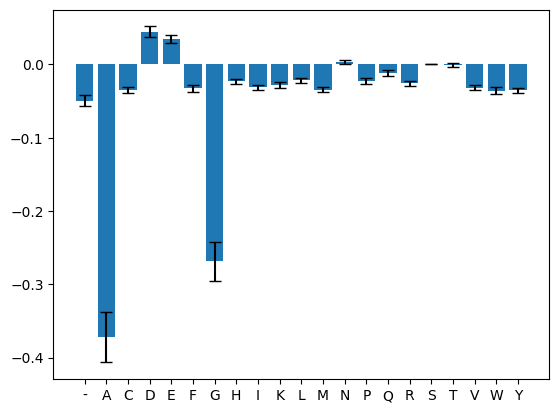

In [18]:
plt.figure()
plt.bar(
    np.arange(21),
    np.mean(np.array(ddes_list), axis=0),
    yerr=np.std(np.array(ddes_list), axis=0) / np.sqrt(10),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()

In [50]:
POS_ALIGN_RED = np.array(['17', '18', '138', '160', '161', '172', '180', '183', '184', '187',
       '188', '189', '192', '213', '215', '216', '217a', '217b', '219',
       '221', '226', '227', '228'])
SEQ_3TGI_RED = 'VGIAPYMVGGGDQVWG--GAGVY'
SEQ_1T8O_RED = 'VNTLPWMAGV-SMVWGS-TSGVY'

subaln_models_folder = Path("../models").glob("TestOfAln*/*npy")
ddes_list = []
for subaln_model in subaln_models_folder:
    model = np.load(subaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    Propose_Mutation_DDE2_mod(J, h, 3, [('S','189')], POS_ALIGN=POS_ALIGN_RED, SEQ_REF=SEQ_3TGI_RED)
    print("\n")

Mutation 2: G226V   ΔΔE = -2.26
Mutation 3: Y228F   ΔΔE = -3.21
Mutation 4: A221E   ΔΔE = -2.64


Mutation 2: G226V   ΔΔE = -2.50
Mutation 3: Y228F   ΔΔE = -3.14
Mutation 4: A221D   ΔΔE = -2.93


Mutation 2: G226V   ΔΔE = -2.37
Mutation 3: Y228F   ΔΔE = -3.41
Mutation 4: A221D   ΔΔE = -2.74


Mutation 2: G226V   ΔΔE = -2.32
Mutation 3: Y228F   ΔΔE = -3.10
Mutation 4: A221E   ΔΔE = -2.79


Mutation 2: G226V   ΔΔE = -2.30
Mutation 3: Y228F   ΔΔE = -3.07
Mutation 4: A221D   ΔΔE = -2.87


Mutation 2: G226V   ΔΔE = -2.40
Mutation 3: Y228F   ΔΔE = -3.38
Mutation 4: A221D   ΔΔE = -2.87


Mutation 2: G226V   ΔΔE = -2.51
Mutation 3: Y228F   ΔΔE = -3.08
Mutation 4: A221E   ΔΔE = -3.04


Mutation 2: G226T   ΔΔE = -2.28
Mutation 3: Y228F   ΔΔE = -3.21
Mutation 4: A221N   ΔΔE = -2.67


Mutation 2: G226V   ΔΔE = -2.64
Mutation 3: Y228F   ΔΔE = -3.23
Mutation 4: A221D   ΔΔE = -2.95


Mutation 2: G226V   ΔΔE = -2.29
Mutation 3: Y228F   ΔΔE = -3.08
Mutation 4: A221D   ΔΔE = -2.51


Mutation 2: G226V   

In [51]:
POS_ALIGN_RED[20]

np.str_('226')

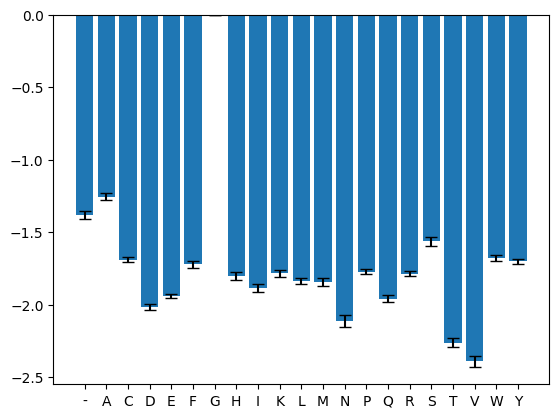

In [53]:
subaln_models_folder = Path("../models").glob("TestOfAln*/*npy")
ddes_list = []
for subaln_model in subaln_models_folder:
    model = np.load(subaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    ddes_list.append(compensatory_ddes(J, i = 11, j = 20, alpha = 3, beta = 16, gamma = 6))

plt.figure()
plt.bar(
    np.arange(21),
    np.mean(np.array(ddes_list), axis=0),
    yerr=np.std(np.array(ddes_list), axis=0) / np.sqrt(10),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()

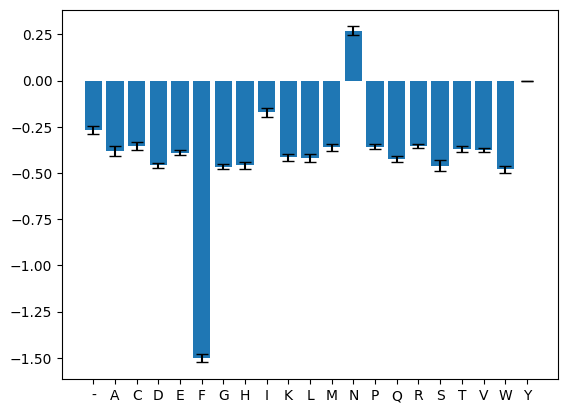

In [98]:
subaln_models_folder = Path("../models").glob("SectorShuffling_SubAln*_Step00_noshuffle/*npy")
ddes_list = []
for subaln_model in subaln_models_folder:
    model = np.load(subaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    ddes_list.append(compensatory_ddes(J, i = 11, j = 22, alpha = 3, beta = 16, gamma = 20))

plt.figure()
plt.bar(
    np.arange(21),
    np.mean(np.array(ddes_list), axis=0),
    yerr=np.std(np.array(ddes_list), axis=0) / np.sqrt(10),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()

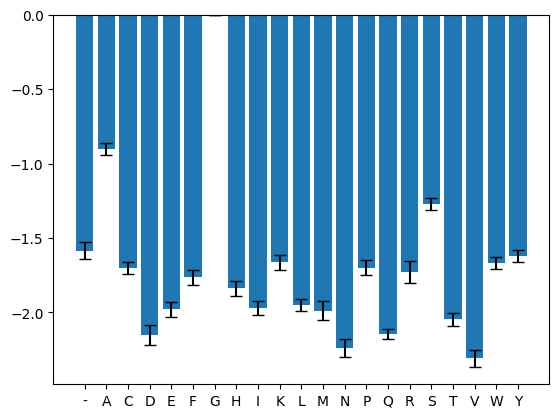

In [99]:
subaln_models_folder = Path("../models").glob("TestBestParamsRed/*npy")
ddes_list = []
for subaln_model in subaln_models_folder:
    model = np.load(subaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    ddes_list.append(compensatory_ddes(J, i = 11, j = 20, alpha = 3, beta = 16, gamma = 6))

plt.figure()
plt.bar(
    np.arange(21),
    np.mean(np.array(ddes_list), axis=0),
    yerr=np.std(np.array(ddes_list), axis=0) / np.sqrt(7),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()

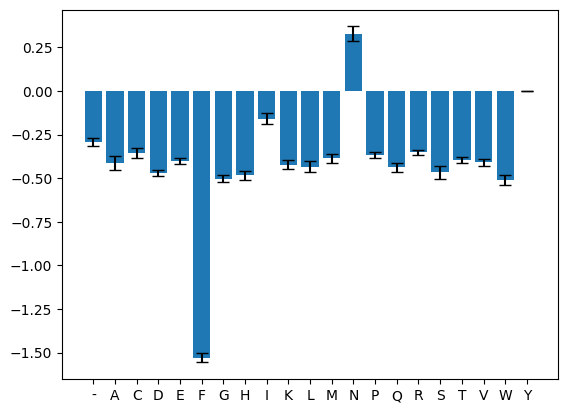

In [100]:
subaln_models_folder = Path("../models").glob("TestBestParamsRed/*npy")
ddes_list = []
for subaln_model in subaln_models_folder:
    model = np.load(subaln_model, allow_pickle=True).item()
    J, h = Zero_Sum_Gauge(model["J"], model["h"])
    ddes_list.append(compensatory_ddes(J, i = 11, j = 22, alpha = 3, beta = 16, gamma = 20))

plt.figure()
plt.bar(
    np.arange(21),
    np.mean(np.array(ddes_list), axis=0),
    yerr=np.std(np.array(ddes_list), axis=0) / np.sqrt(7),
    capsize=4
)
plt.xticks(ticks=np.arange(21), labels="-ACDEFGHIKLMNPQRSTVWY")
plt.show()